# Importing Tools

In [15]:
import time
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from PIL import Image
import psutil
import gc

# Funtions

In [16]:
def initialize_models():
  # Create a dictionary with model IDs as keys and (model, name) tuples as values
  models_dict = {
      1: (torchvision.models.efficientnet_b0(pretrained=True), "EfficientNet"),
      2: (torchvision.models.resnet50(pretrained=True), "ResNet50"),
      3: (torchvision.models.vit_b_16(pretrained=True), "ViT"),
      4: (torchvision.models.squeezenet1_0(pretrained=True), "SqueezeNet"),
      5: (torchvision.models.inception_v3(pretrained=True), "Inception-v3"),
      6: (torchvision.models.mobilenet_v3_large(pretrained=True), "MobileNet-v3")
  }
  return models_dict

In [17]:
def select_models():
  # Get available models
  models_dict = initialize_models()

  # Display available models
  print("Please specify the model(s) to be tested")
  print("1. EfficientNet\n2. ResNet\n3. ViT\n4. SqueezeNet\n5. Inception\n6. MobileNetV3\n\n 0. exit")

  # Let user select models
  models = []
  model_names = []

  while True:
    model_id = int(input())
    if model_id == 0:
      break

    if model_id in models_dict:
      model, name = models_dict[model_id]
      models.append(model)
      model_names.append(name)
      print(f"Added {name}")
    else:
      print(f"Invalid model ID: {model_id}")

  return models, model_names

In [18]:
def train_model(model, model_name, trainloader, testloader, device, num_epochs=5):
    time_start = time.time()
    model.to(device)  # Move the entire model to the device (CPU/GPU)

    # Define classes based on the dataset
    classes = trainloader.dataset.classes
    print(f"Training with classes: {classes}")

    # Customize the classifier for each model architecture
    if 'efficientnet' in model_name.lower():
        num_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(num_features, len(classes)).to(device)

    elif 'resnet' in model_name.lower():
        num_features = model.fc.in_features
        model.fc = nn.Linear(num_features, len(classes)).to(device)

    elif 'vit' in model_name.lower():
        num_features = model.heads.head.in_features
        model.heads.head = nn.Linear(num_features, len(classes)).to(device)

    elif 'squeezenet' in model_name.lower():
        model.classifier[1] = nn.Conv2d(512, len(classes), kernel_size=1).to(device)

    elif 'inception' in model_name.lower():
        num_features = model.fc.in_features
        model.fc = nn.Linear(num_features, len(classes)).to(device)
        model.aux_logits = False
        model.AuxLogits = None

    elif 'mobilenet' in model_name.lower():
        num_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(num_features, len(classes)).to(device)

    else:
        raise ValueError(f"Model architecture {model_name} not supported")

    criterion = nn.CrossEntropyLoss()
    optimizer_fine_tuning = optim.Adam(model.parameters(), lr=0.0001)

    # Special transform for Inception which expects 299x299 images
    transform_inception = None
    if 'inception' in model_name.lower():
        transform_inception = transforms.Compose([
            transforms.Resize(299),
            transforms.CenterCrop(299),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    # Training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        running_loss = 0.0
        correct = 0
        total = 0

        for i, data in enumerate(trainloader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)

            # Handle inputs for Inception which expect 299x299 images
            if 'inception' in model_name.lower() and (inputs.shape[2] != 299 or inputs.shape[3] != 299):
                # Use a specialized transform function
                batch_size = inputs.size(0)
                resized_inputs = torch.zeros(batch_size, 3, 299, 299).to(device)

                # Process each image in the batch separately
                for j in range(batch_size):
                    # Convert tensor to PIL Image
                    img = transforms.ToPILImage()(inputs[j].cpu())
                    # Apply transformations and convert back to tensor
                    resized_inputs[j] = transform_inception(img).to(device)

                inputs = resized_inputs

            optimizer_fine_tuning.zero_grad()

            # Forward pass
            try:
                outputs = model(inputs)

                # Some models like inception may return tuples during training
                if isinstance(outputs, tuple):
                    outputs = outputs[0]  # Use the main output

                loss = criterion(outputs, labels)
                loss.backward()
                optimizer_fine_tuning.step()

                running_loss += loss.item()

                # Calculate accuracy
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            except RuntimeError as e:
                print(f"Error processing batch: {e}")
                print(f"Input shape: {inputs.shape}")
                continue  # Skip this batch and continue with the next one

        epoch_loss = running_loss / len(trainloader)
        epoch_acc = 100 * correct / total if total > 0 else 0
        print(f"Epoch {epoch+1}, {model_name} - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

    time_stop = time.time()
    time_elapsed = time_stop - time_start
    print(f"Training time for {model_name}: {time_elapsed:.2f} seconds")

    return model, time_elapsed

In [19]:
def evaluate_model(model, model_name, testloader, device):
    model.eval()  # Set to evaluation mode
    classes = testloader.dataset.classes  # Get class names

    correct = 0
    total = 0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(device), data[1].to(device)

            # Handle Inception inputs
            if 'inception' in model_name.lower() and (images.shape[2] != 299 or images.shape[3] != 299):
                batch_size = images.size(0)
                resized_inputs = torch.zeros(batch_size, 3, 299, 299).to(device)

                for j in range(batch_size):
                    img = transforms.ToPILImage()(images[j].cpu())
                    resized_inputs[j] = transforms.Compose([
                        transforms.Resize(299),
                        transforms.CenterCrop(299),
                        transforms.ToTensor(),
                        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                    ])(img).to(device)

                images = resized_inputs

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    score_metrics = classification_report(y_true, y_pred, target_names=classes, output_dict=True)
    accuracy = correct / total
    weighted_avg = score_metrics['weighted avg']

    # Display results
    print(f"Model: {model_name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Weighted Average Metrics:")
    print(f"Precision: {weighted_avg['precision']:.4f}")
    print(f"Recall: {weighted_avg['recall']:.4f}")
    print(f"F1-Score: {weighted_avg['f1-score']:.4f}")
    print("-" * 60)

    return {
        'accuracy': accuracy,
        'precision': weighted_avg['precision'],
        'recall': weighted_avg['recall'],
        'f1-score': weighted_avg['f1-score']
    }

In [20]:
def measure_inference_time(model, testloader, device, num_runs=50):
    model.eval()  # Set model to evaluation mode

    # Check if we're using Inception model
    is_inception = isinstance(model, torchvision.models.inception.Inception3)
    inception_transform = None

    if is_inception:
        inception_transform = transforms.Compose([
            transforms.Resize(299),
            transforms.CenterCrop(299),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    # Warm-up runs
    with torch.no_grad():
        warm_up_loader = iter(testloader)
        for _ in range(min(5, len(testloader))):
            try:
                inputs, _ = next(warm_up_loader)

                # Handle Inception input size
                if is_inception and (inputs.shape[2] != 299 or inputs.shape[3] != 299):
                    batch_size = inputs.size(0)
                    resized_inputs = torch.zeros(batch_size, 3, 299, 299).to(device)

                    for j in range(batch_size):
                        img = transforms.ToPILImage()(inputs[j].cpu())
                        resized_inputs[j] = inception_transform(img).to(device)

                    inputs = resized_inputs
                else:
                    inputs = inputs.to(device)

                _ = model(inputs)
            except StopIteration:
                break

    # Actual timing runs
    times = []
    with torch.no_grad():
        test_loader = iter(testloader)
        for _ in range(min(num_runs, len(testloader))):
            try:
                inputs, _ = next(test_loader)

                # Handle Inception input size
                if is_inception and (inputs.shape[2] != 299 or inputs.shape[3] != 299):
                    batch_size = inputs.size(0)
                    resized_inputs = torch.zeros(batch_size, 3, 299, 299).to(device)

                    for j in range(batch_size):
                        img = transforms.ToPILImage()(inputs[j].cpu())
                        resized_inputs[j] = inception_transform(img).to(device)

                    inputs = resized_inputs
                else:
                    inputs = inputs.to(device)

                # Timing with proper synchronization
                if device.type == 'cuda':
                    torch.cuda.synchronize()

                start_time = time.time()
                _ = model(inputs)

                if device.type == 'cuda':
                    torch.cuda.synchronize()

                end_time = time.time()
                times.append(end_time - start_time)

            except StopIteration:
                break

    # Make sure we have at least one measurement
    if not times:
        print(f"Warning: No valid inference times collected")
        return 0.0

    # Calculate average inference time per batch
    avg_time = sum(times) / len(times)

    # Calculate inference time per image
    batch_size = testloader.batch_size
    avg_time_per_img = avg_time / batch_size

    return avg_time_per_img * 1000  # Convert to milliseconds per image

In [21]:
def measure_resource_utilization(model, testloader, device, num_runs=20):
    """Measure CPU and GPU resource utilization during inference."""
    model.eval()

    # Clear memory before measurements
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()

    # Warm-up runs to stabilize measurements
    with torch.no_grad():
        warm_up_loader = iter(testloader)
        for _ in range(min(5, len(testloader))):
            try:
                inputs, _ = next(warm_up_loader)
                inputs = inputs.to(device)

                # Handle Inception model separately
                if isinstance(model, torchvision.models.inception.Inception3):
                    if inputs.shape[2] != 299 or inputs.shape[3] != 299:
                        batch_size = inputs.size(0)
                        resized_inputs = torch.zeros(batch_size, 3, 299, 299).to(device)
                        for j in range(batch_size):
                            img = transforms.ToPILImage()(inputs[j].cpu())
                            resized_inputs[j] = transforms.ToTensor()(transforms.Resize((299, 299))(img)).to(device)
                        inputs = resized_inputs

                _ = model(inputs)
                if device.type == 'cuda':
                    torch.cuda.synchronize()
            except StopIteration:
                break

    # Measurements
    cpu_utils = []
    gpu_mem_usages = []
    gpu_utils = []

    with torch.no_grad():
        test_loader = iter(testloader)
        
        # Record baseline memory usage before any model inference
        if device.type == 'cuda':
            torch.cuda.synchronize()
            baseline_mem = torch.cuda.memory_allocated() / (1024 * 1024)  # MB
        
        for _ in range(min(num_runs, len(testloader))):
            try:
                # Clear memory before each measurement
                if device.type == 'cuda':
                    torch.cuda.empty_cache()
                gc.collect()

                inputs, _ = next(test_loader)
                inputs = inputs.to(device)

                # Handle Inception model
                if isinstance(model, torchvision.models.inception.Inception3):
                    if inputs.shape[2] != 299 or inputs.shape[3] != 299:
                        batch_size = inputs.size(0)
                        resized_inputs = torch.zeros(batch_size, 3, 299, 299).to(device)
                        for j in range(batch_size):
                            img = transforms.ToPILImage()(inputs[j].cpu())
                            resized_inputs[j] = transforms.ToTensor()(transforms.Resize((299, 299))(img)).to(device)
                        inputs = resized_inputs

                # Measure CPU usage
                cpu_util = psutil.cpu_percent(interval=0.1)
                cpu_utils.append(cpu_util)
                
                # GPU measurements
                if device.type == 'cuda':
                    # Capture peak memory during operation
                    torch.cuda.reset_peak_memory_stats()
                    torch.cuda.synchronize()
                    
                    # Run forward pass
                    start_time = time.time()
                    _ = model(inputs)
                    torch.cuda.synchronize()
                    
                    # Memory measurement - get peak memory allocated during this run
                    peak_mem = torch.cuda.max_memory_allocated() / (1024 * 1024)  # MB
                    gpu_mem_usage = peak_mem - baseline_mem
                    gpu_mem_usage = max(0, gpu_mem_usage)  # Ensure non-negative value
                    gpu_mem_usages.append(gpu_mem_usage)
                    
                    # Measure GPU utilization using nvidia-smi if available
                    try:
                        import subprocess
                        result = subprocess.check_output(['nvidia-smi', '--query-gpu=utilization.gpu', '--format=csv,noheader,nounits'])
                        gpu_util = float(result.decode('utf-8').strip())
                        gpu_utils.append(gpu_util)
                    except (subprocess.SubprocessError, FileNotFoundError, ValueError):
                        # Fallback if nvidia-smi command fails - estimate based on memory
                        inference_time = time.time() - start_time
                        # More balanced estimation formula - still an approximation
                        estimated_util = min(95.0, (gpu_mem_usage / 10) + (1 / max(0.001, inference_time)) * 2)
                        gpu_utils.append(estimated_util)

            except StopIteration:
                break

    # Calculate averages
    avg_cpu_util = sum(cpu_utils) / len(cpu_utils) if cpu_utils else 0.0
    result = {'cpu_utilization': avg_cpu_util}

    if device.type == 'cuda':
        avg_gpu_mem = sum(gpu_mem_usages) / len(gpu_mem_usages) if gpu_mem_usages else 0.0
        avg_gpu_util = sum(gpu_utils) / len(gpu_utils) if gpu_utils else 0.0

        result.update({
            'gpu_utilization': avg_gpu_util,
            'VRAM_usage_mb': avg_gpu_mem
        })

    return result

In [22]:
# def monitor_gpu_utilization(model, testloader, device, duration=2.0):
#     """
#     Monitor actual GPU utilization while running inference with a model.
    
#     Args:
#         model: PyTorch model to test
#         testloader: DataLoader with test data
#         device: Device to run on (should be CUDA)
#         duration: How long to monitor GPU in seconds
    
#     Returns:
#         avg_utilization: Average GPU utilization percentage
#     """
#     if device.type != 'cuda':
#         return 0.0  # No GPU utilization on CPU
    
#     try:
#         import subprocess
#         import threading
#         import time
#         import numpy as np
        
#         # Function to sample GPU utilization in a separate thread
#         def sample_gpu():
#             nonlocal utils
#             while sampling:
#                 try:
#                     result = subprocess.check_output(
#                         ['nvidia-smi', '--query-gpu=utilization.gpu', '--format=csv,noheader,nounits'],
#                         stderr=subprocess.DEVNULL
#                     )
#                     util = float(result.decode('utf-8').strip())
#                     utils.append(util)
#                 except (subprocess.SubprocessError, ValueError):
#                     pass
#                 time.sleep(0.1)  # Sample every 100ms
        
#         model.eval()
#         utils = []
#         sampling = True
        
#         # Start sampling thread
#         sample_thread = threading.Thread(target=sample_gpu)
#         sample_thread.daemon = True
#         sample_thread.start()
        
#         # Run inference
#         start_time = time.time()
#         with torch.no_grad():
#             data_iter = iter(testloader)
#             while time.time() - start_time < duration:
#                 try:
#                     inputs, _ = next(data_iter)
#                 except StopIteration:
#                     data_iter = iter(testloader)
#                     inputs, _ = next(data_iter)
                
#                 inputs = inputs.to(device)
                
#                 # Handle Inception model
#                 if isinstance(model, torchvision.models.inception.Inception3):
#                     if inputs.shape[2] != 299 or inputs.shape[3] != 299:
#                         batch_size = inputs.size(0)
#                         resized_inputs = torch.zeros(batch_size, 3, 299, 299).to(device)
#                         for j in range(batch_size):
#                             img = transforms.ToPILImage()(inputs[j].cpu())
#                             resized_inputs[j] = transforms.ToTensor()(transforms.Resize((299, 299))(img)).to(device)
#                         inputs = resized_inputs
                
#                 torch.cuda.synchronize()
#                 _ = model(inputs)
#                 torch.cuda.synchronize()
        
#         # Stop sampling and calculate average
#         sampling = False
#         sample_thread.join(timeout=1.0)
        
#         if utils:
#             # Discard first few readings (warm-up)
#             if len(utils) > 5:
#                 utils = utils[5:]
#             avg_utilization = np.mean(utils) if utils else 0.0
#             return avg_utilization
#         else:
#             return 0.0
    
#     except Exception as e:
#         print(f"Error monitoring GPU: {e}")
#         return 0.0  # Fallback value

In [23]:
def measure_model_size(model, device='cuda'):
    """
    Measure model'size (Parameter's size).
    
    Args:
        model: The PyTorch model to profile
        device: Device to run the model on
    
    Returns:
        total_params_mb: Size of model parameters in MB
    """
    
    # Calculate model parameters size
    total_params = sum(p.numel() for p in model.parameters())
    total_params_mb = total_params * 4 / (1024 * 1024)  # 4 bytes per float32 parameter
    
    # Final cleanup
    if device == 'cuda':
        torch.cuda.empty_cache()
    
    return total_params_mb

In [24]:
def visualize_results(results_df):
    """
    Enhanced visualization of model benchmark results with multiple plots for better insight.
    """
    if results_df is None or results_df.empty:
        print("No results to visualize")
        return
    
    # Round values for display
    results_df_display = results_df.round(3)
    
    # Set up the figure layout
    fig = plt.figure(figsize=(18, 12))
    
    # 1. Summary table at the top
    ax_table = plt.subplot2grid((3, 2), (0, 0), colspan=2)
    
    # Create the table
    data = results_df_display.values
    models = results_df_display.index
    metrics = results_df_display.columns
    
    # Determine which values to highlight
    # Highlight maximum values for accuracy metrics
    performance_metrics = ['accuracy', 'precision', 'recall', 'f1-score']
    perf_indices = []
    
    for metric in performance_metrics:
        if metric in results_df_display.columns:
            idx = list(results_df_display.columns).index(metric)
            max_idx = results_df_display[metric].values.argmax()
            perf_indices.append((max_idx, idx))
    
    # Highlight minimum value for time metrics
    time_metrics = ['inference_time_ms', 'training_time']
    min_indices = []
    
    for metric in time_metrics:
        if metric in results_df_display.columns:
            idx = list(results_df_display.columns).index(metric)
            min_idx = results_df_display[metric].values.argmin()
            min_indices.append((min_idx, idx))
    
    # Create a color array with all white cells initially
    cell_colors = np.full(data.shape + (4,), [1, 1, 1, 1])  # RGBA for white
    
    # Set color for best performance metrics (green)
    for i, j in perf_indices:
        cell_colors[i, j] = [0, 1, 0, 1]  # RGBA for green
    
    # Set color for best time metrics (green)
    for i, j in min_indices:
        cell_colors[i, j] = [0, 1, 0, 1]  # RGBA for green
    
    # Create the table
    table = ax_table.table(cellText=data,
                    rowLabels=models,
                    colLabels=metrics,
                    loc='center',
                    cellColours=cell_colors)
    
    ax_table.axis('off')
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.1, 1.4)
    
    # Customize header row
    for j in range(len(metrics)):
        table[(0, j)].set_text_props(weight='bold', color='white')
        table[(0, j)].set_facecolor('#4472C4')
    
    # Customize row labels
    for i in range(len(models)):
        table[(i+1, -1)].set_text_props(weight='bold')
    
    plt.title('Model Performance Metrics Comparison', fontsize=16, y=0.8)
    
    # 2. Accuracy metrics plot
    ax1 = plt.subplot2grid((3, 2), (1, 0))
    if all(metric in results_df for metric in ['accuracy', 'precision', 'recall', 'f1-score']):
        results_df[['accuracy', 'precision', 'recall', 'f1-score']].plot(kind='bar', ax=ax1)
        ax1.set_title('Accuracy Metrics')
        ax1.set_ylim([0, 1.0])
        ax1.set_ylabel('Score')
        ax1.legend(loc='lower right')
        
        # Add value annotations
        for i, v in enumerate(results_df['accuracy']):
            ax1.text(i-0.3, v+0.02, f"{v:.3f}", color='black', fontweight='bold', fontsize=9)
    
    # 3. Speed/Resource metrics
    ax2 = plt.subplot2grid((3, 2), (1, 1))
    if 'inference_time_ms' in results_df:
        ax2.bar(range(len(models)), results_df['inference_time_ms'], color='skyblue')
        ax2.set_title('Inference Time (ms)')
        ax2.set_xticks(range(len(models)))
        ax2.set_xticklabels(models, rotation=45)
        ax2.set_ylabel('Time (ms)')
        
        # Add value annotations
        for i, v in enumerate(results_df['inference_time_ms']):
            ax2.text(i-0.2, v+0.1, f"{v:.2f}", color='black', fontweight='bold', fontsize=9)
    
    # 4. Memory usage
    ax3 = plt.subplot2grid((3, 2), (2, 0))
    if 'VRAM_usage_mb' in results_df:
        VRAM_usage = results_df['VRAM_usage_mb']
        ax3.bar(range(len(models)), VRAM_usage, color='lightgreen')
        ax3.set_title('VRAM Usage (MB)')
        ax3.set_xticks(range(len(models)))
        ax3.set_xticklabels(models, rotation=45)
        ax3.set_ylabel('VRAM (MB)')
        
        # Add value annotations
        for i, v in enumerate(VRAM_usage):
            ax3.text(i-0.2, v+0.1, f"{v:.1f}", color='black', fontweight='bold', fontsize=9)
    
    # 5. GPU Utilization
    ax4 = plt.subplot2grid((3, 2), (2, 1))
    if 'gpu_utilization' in results_df:
        ax4.bar(range(len(models)), results_df['gpu_utilization'], color='salmon')
        ax4.set_title('GPU Utilization (%)')
        ax4.set_xticks(range(len(models)))
        ax4.set_xticklabels(models, rotation=45)
        ax4.set_ylabel('Utilization (%)')
        ax4.set_ylim([0, 100])
        
        # Add value annotations
        for i, v in enumerate(results_df['gpu_utilization']):
            ax4.text(i-0.2, v+2, f"{v:.1f}", color='black', fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('enhanced_benchmark_results.png', dpi=300, bbox_inches='tight')
    plt.show()

# Implementation

In [25]:
data_dir = 'C:/Users/Kp/Desktop/()/Code/DataSci/lab12_datasets/hymenoptera_data'
# Check if the data directory exists
if not os.path.exists(data_dir):
    print(f"Error: Data directory '{data_dir}' not found. Please download and organize the dataset.")
    exit()
print(f"Found dataset at {data_dir}")

Found dataset at C:/Users/Kp/Desktop/()/Code/DataSci/lab12_datasets/hymenoptera_data


Using device: cuda:0


c:\Users\Kp\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Kp\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
c:\Users\Kp\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Wei

Please specify the model(s) to be tested
1. EfficientNet
2. ResNet
3. ViT
4. SqueezeNet
5. Inception
6. MobileNetV3

 0. exit
Added EfficientNet
Added ResNet50
Added ViT
Added SqueezeNet
Added Inception-v3
Added MobileNet-v3

--- Benchmarking EfficientNet ---
Training with classes: ['ants', 'bees']
Epoch 1, EfficientNet - Loss: 0.6383, Accuracy: 67.21%
Epoch 2, EfficientNet - Loss: 0.4786, Accuracy: 89.34%
Epoch 3, EfficientNet - Loss: 0.3743, Accuracy: 93.44%
Epoch 4, EfficientNet - Loss: 0.3370, Accuracy: 92.21%
Epoch 5, EfficientNet - Loss: 0.2675, Accuracy: 92.21%
Training time for EfficientNet: 27.11 seconds
Model: EfficientNet
Accuracy: 0.9877
Weighted Average Metrics:
Precision: 0.9880
Recall: 0.9877
F1-Score: 0.9877
------------------------------------------------------------

--- Benchmarking ResNet50 ---
Training with classes: ['ants', 'bees']
Epoch 1, ResNet50 - Loss: 0.4202, Accuracy: 81.56%
Epoch 2, ResNet50 - Loss: 0.1285, Accuracy: 95.49%
Epoch 3, ResNet50 - Loss: 0.1105

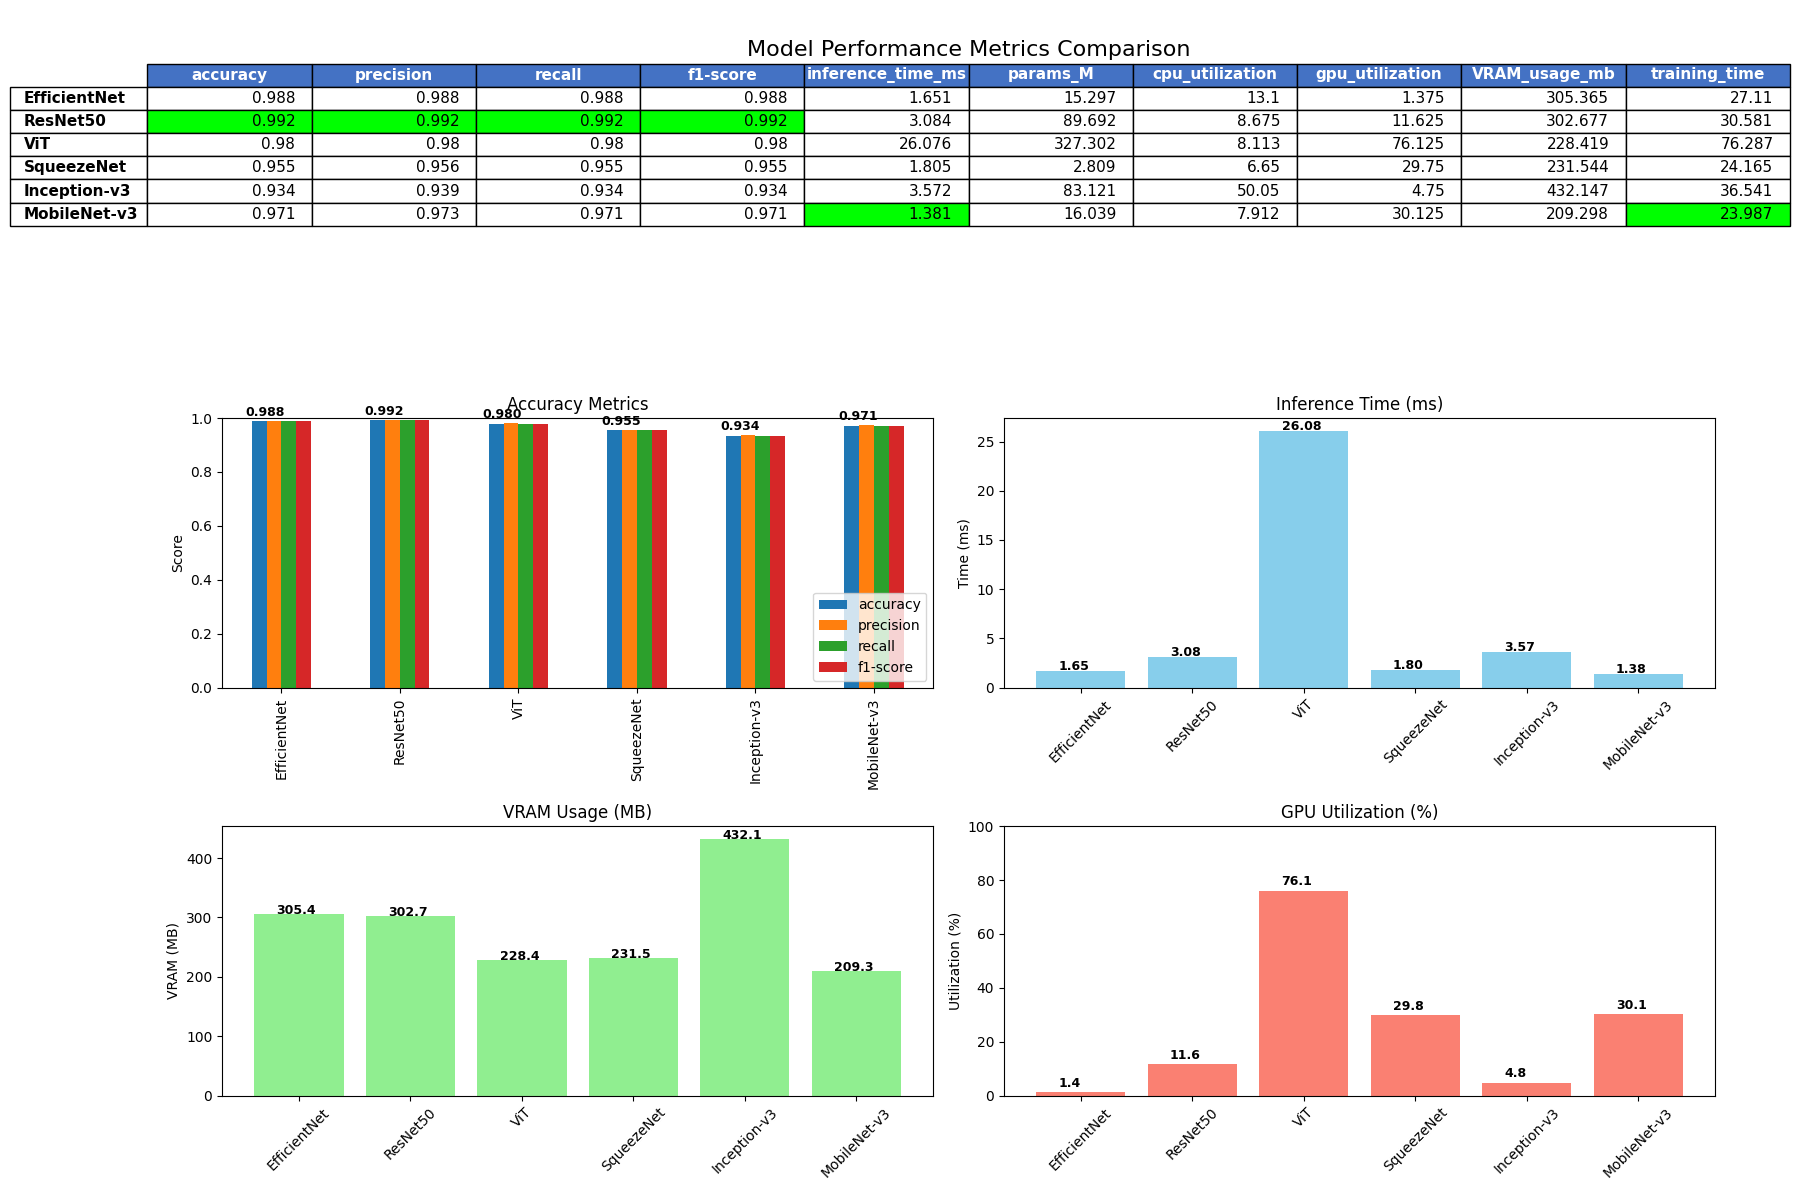

In [26]:
# Set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set up data transformations
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load datasets
trainset = torchvision.datasets.ImageFolder(root=os.path.join(data_dir, 'train'), transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True, num_workers=2)

testset = torchvision.datasets.ImageFolder(root=os.path.join(data_dir, 'train'), transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False, num_workers=2)

# Select models to benchmark
models, model_names = select_models()

# Dictionary to store results
all_results = {}

# Train and evaluate each model
for i, (model, name) in enumerate(zip(models, model_names)):
    print(f"\n--- Benchmarking {name} ---")

    try:
        # Train the model
        trained_model, train_time = train_model(model, name, trainloader, testloader, device)

        # Evaluate the model
        metrics = evaluate_model(trained_model, name, testloader, device)

        # Measure inference time
        inference_time = measure_inference_time(model, testloader, device)
        metrics['inference_time_ms'] = inference_time

        # Profile model memory - more accurate approach
        params_size = measure_model_size(model, device)
        metrics['params_M'] = params_size

        # Measure resource utilization with improved method
        resources = measure_resource_utilization(model, testloader, device)
        metrics.update(resources)

        # Measure actual GPU utilization with nvidia-smi if on CUDA
        # if device.type == 'cuda':
        #     actual_gpu_util = monitor_gpu_utilization(model, testloader, device, duration=3.0)
        #     metrics['gpu_utilization'] = actual_gpu_util

        # Add training time to metrics
        metrics['training_time'] = train_time

        # Store results
        all_results[name] = metrics

    except Exception as e:
        print(f"Error with {name}: {e}")
        import traceback
        traceback.print_exc()
        continue

# Create DataFrame from results
if all_results:
    results_df = pd.DataFrame.from_dict(all_results, orient='index')

    # Display and save results
    print("\nFinal Results:")
    print(results_df)

    results_df.to_csv('benchmark_results.csv')

    # Visualize the results
    visualize_results(results_df)

# Exportation

In [27]:
for i in range(len(models)):
    print(f"{i+1}. {model_names[i]}")

while True:
    option = int(input("Select a model to be exported: "))
    if option not in range(len(models)+1):
        print("Invalid option. Please select a valid model number.")
        continue
    else:
        break

modelname = {
    'EfficientNet': 'efficientnet_b0',
    'ResNet50': 'resnet50',
    'ViT': 'vit_b_16',
    'SqueezeNet': 'squeezenet1_0',
    'Inception-v3': 'inception_v3',
    'MobileNet-v3': 'mobilenet_v3_large'
}

print(f"Exporting {model_names[option-1]} model weights...")
torch.save({
    'model_state_dict': models[option - 1].state_dict(),
    'model_type': modelname[model_names[option-1]],
    'num_classes': 2
}, 'model.pth')
print(f"Model exported successfully to 'model.pth'")

1. EfficientNet
2. ResNet50
3. ViT
4. SqueezeNet
5. Inception-v3
6. MobileNet-v3
Exporting SqueezeNet model weights...
Model exported successfully to 'model.pth'
